# Análise do Desempenho de Estudantes de Português

Este notebook analisa os fatores que influenciam a nota final (G3) de alunos de português em escolas de Portugal.

**Estrutura:**
1. Importações e carregamento dos dados
2. Visão geral dos dados
3. Análise Exploratória —> Fatores Sociais
4. Análise Exploratória —> Fatores Acadêmicos
5. Correlações com a nota final
6. Treinamento do Modelo
7. Avaliação do Modelo

---
## 1. Importações e Carregamento dos Dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

#Carregamento
df = pd.read_csv(r"student-por.csv")

print(f'Dados carregados com sucesso!')
print(f'   Alunos: {df.shape[0]} | Colunas: {df.shape[1]}')

Dados carregados com sucesso!
   Alunos: 649 | Colunas: 33


---
## 2. Visão Geral dos Dados

In [4]:
#Primeiras linhas
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
#Informações gerais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
#Estatísticas descritivas das colunas numéricas
df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


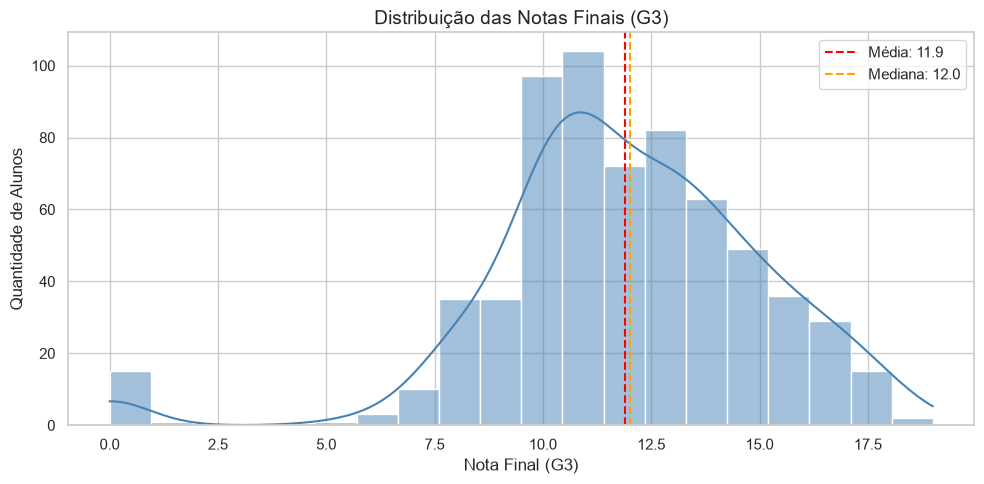

In [7]:
#Distribuição da nota final (G3)
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.axvline(df['G3'].mean(), color='red', linestyle='--', label=f"Média: {df['G3'].mean():.1f}")
plt.axvline(df['G3'].median(), color='orange', linestyle='--', label=f"Mediana: {df['G3'].median():.1f}")
plt.title('Distribuição das Notas Finais (G3)', fontsize=14)
plt.xlabel('Nota Final (G3)')
plt.ylabel('Quantidade de Alunos')
plt.legend()
plt.tight_layout()
plt.show()

---
## 3. Análise Exploratória —> Fatores Sociais

Aqui investigamos como fatores fora da escola influenciam a nota final.

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\2535744864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_genero, x='sex', y='G3', ax=axes[0], palette='pastel')


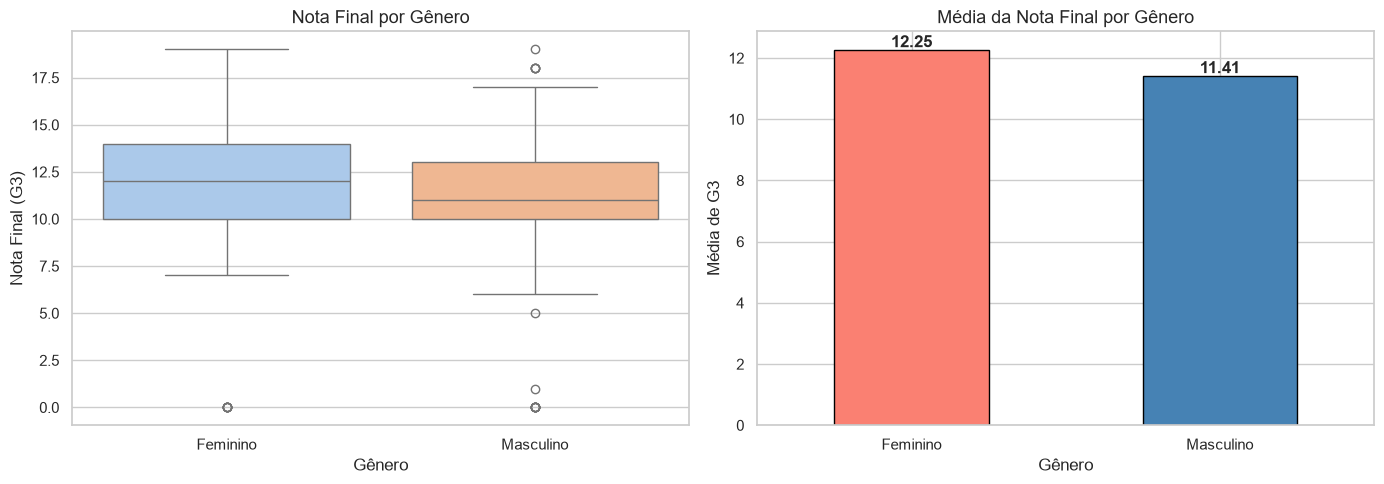

In [8]:
#Nota média por gênero
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Boxplot
df_genero = df.copy()
df_genero['sex'] = df_genero['sex'].map({'F': 'Feminino', 'M': 'Masculino'})

sns.boxplot(data=df_genero, x='sex', y='G3', ax=axes[0], palette='pastel')
axes[0].set_title('Nota Final por Gênero', fontsize=13)
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Nota Final (G3)')

#Médias
medias = df_genero.groupby('sex')['G3'].mean()
medias.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='black')
axes[1].set_title('Média da Nota Final por Gênero', fontsize=13)
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Média de G3')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(medias):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\1708636135.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Dalc', y='G3', ax=axes[0], palette='Oranges')
C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\1708636135.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=axes[1], palette='Reds')


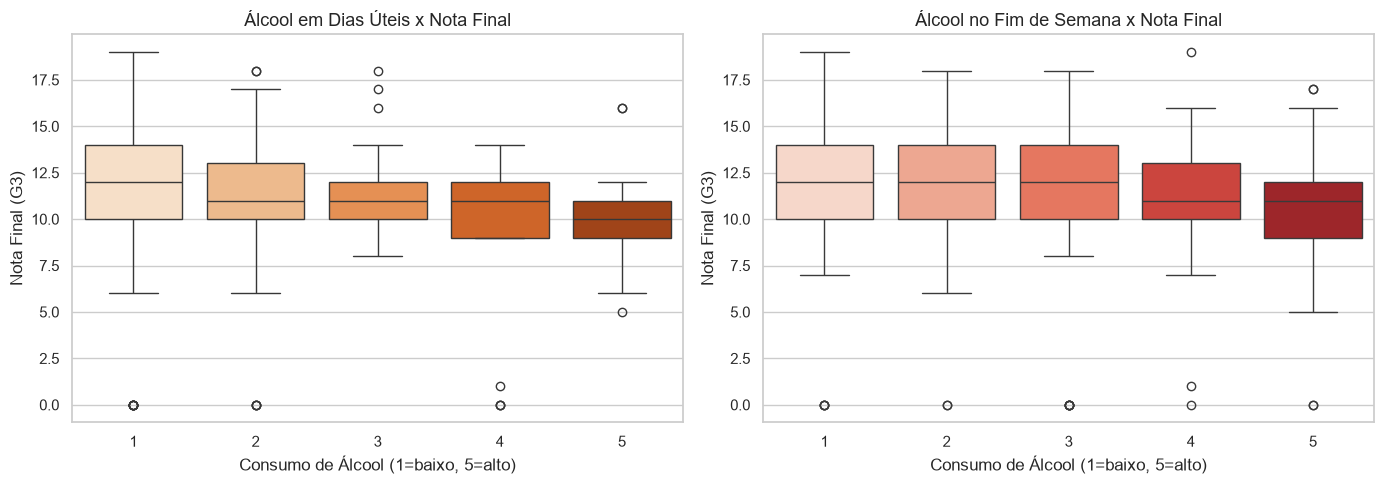

In [9]:
#Álcool x Nota Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Dalc', y='G3', ax=axes[0], palette='Oranges')
axes[0].set_title('Álcool em Dias Úteis x Nota Final', fontsize=13)
axes[0].set_xlabel('Consumo de Álcool (1=baixo, 5=alto)')
axes[0].set_ylabel('Nota Final (G3)')

sns.boxplot(data=df, x='Walc', y='G3', ax=axes[1], palette='Reds')
axes[1].set_title('Álcool no Fim de Semana x Nota Final', fontsize=13)
axes[1].set_xlabel('Consumo de Álcool (1=baixo, 5=alto)')
axes[1].set_ylabel('Nota Final (G3)')

plt.tight_layout()
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\1681178988.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_famsup, x='famsup', y='G3', ax=axes[0], palette='Greens')


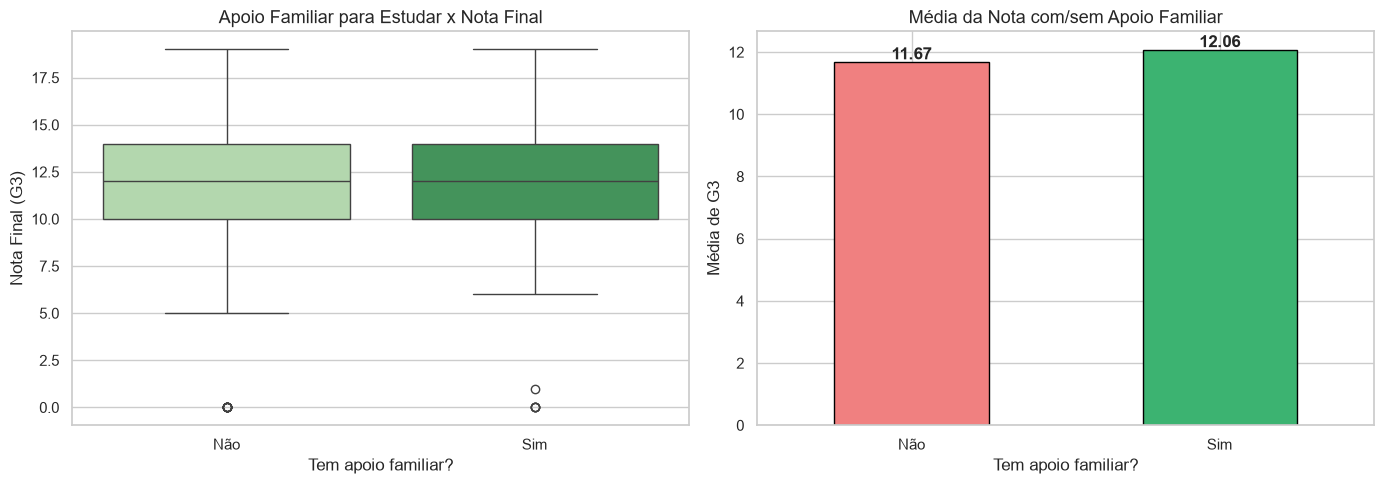

In [10]:
#Apoio familiar x Nota Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_famsup = df.copy()
df_famsup['famsup'] = df_famsup['famsup'].map({'yes': 'Sim', 'no': 'Não'})

sns.boxplot(data=df_famsup, x='famsup', y='G3', ax=axes[0], palette='Greens')
axes[0].set_title('Apoio Familiar para Estudar x Nota Final', fontsize=13)
axes[0].set_xlabel('Tem apoio familiar?')
axes[0].set_ylabel('Nota Final (G3)')

medias_fam = df_famsup.groupby('famsup')['G3'].mean()
medias_fam.plot(kind='bar', ax=axes[1], color=['lightcoral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('Média da Nota com/sem Apoio Familiar', fontsize=13)
axes[1].set_xlabel('Tem apoio familiar?')
axes[1].set_ylabel('Média de G3')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(medias_fam):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\2965319106.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='goout', y='G3', ax=axes[0], palette='Purples')
C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\2965319106.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_net, x='internet', y='G3', ax=axes[1], palette='Blues')


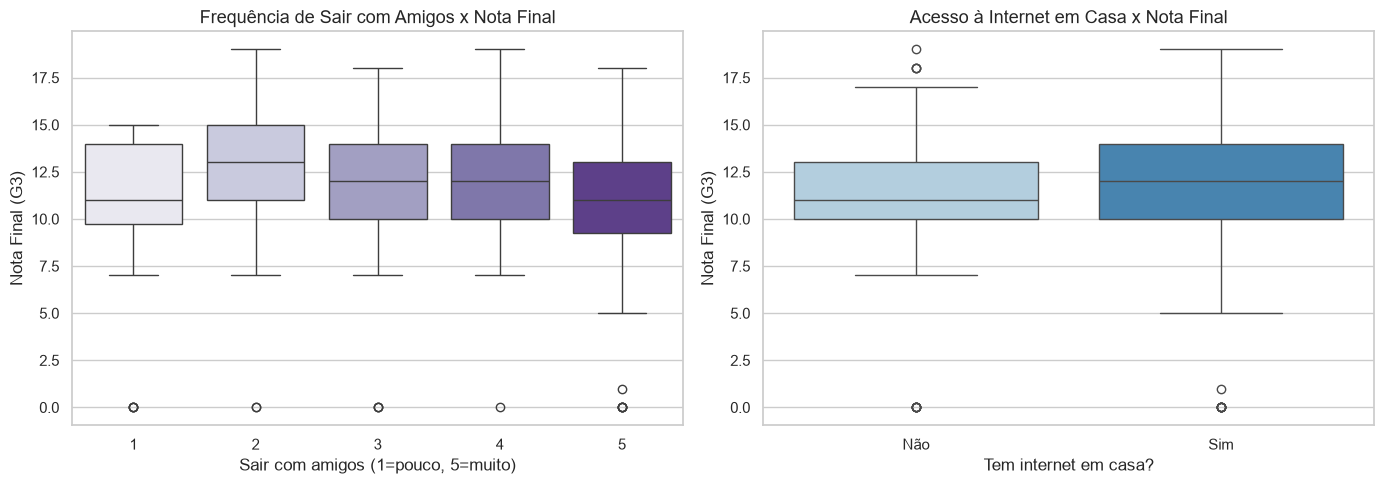

In [11]:
#Sair com amigos x Nota Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='goout', y='G3', ax=axes[0], palette='Purples')
axes[0].set_title('Frequência de Sair com Amigos x Nota Final', fontsize=13)
axes[0].set_xlabel('Sair com amigos (1=pouco, 5=muito)')
axes[0].set_ylabel('Nota Final (G3)')

#Internet x Nota
df_net = df.copy()
df_net['internet'] = df_net['internet'].map({'yes': 'Sim', 'no': 'Não'})
sns.boxplot(data=df_net, x='internet', y='G3', ax=axes[1], palette='Blues')
axes[1].set_title('Acesso à Internet em Casa x Nota Final', fontsize=13)
axes[1].set_xlabel('Tem internet em casa?')
axes[1].set_ylabel('Nota Final (G3)')

plt.tight_layout()
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\692932449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_addr, x='address', y='G3', ax=axes[0], palette='Set2')


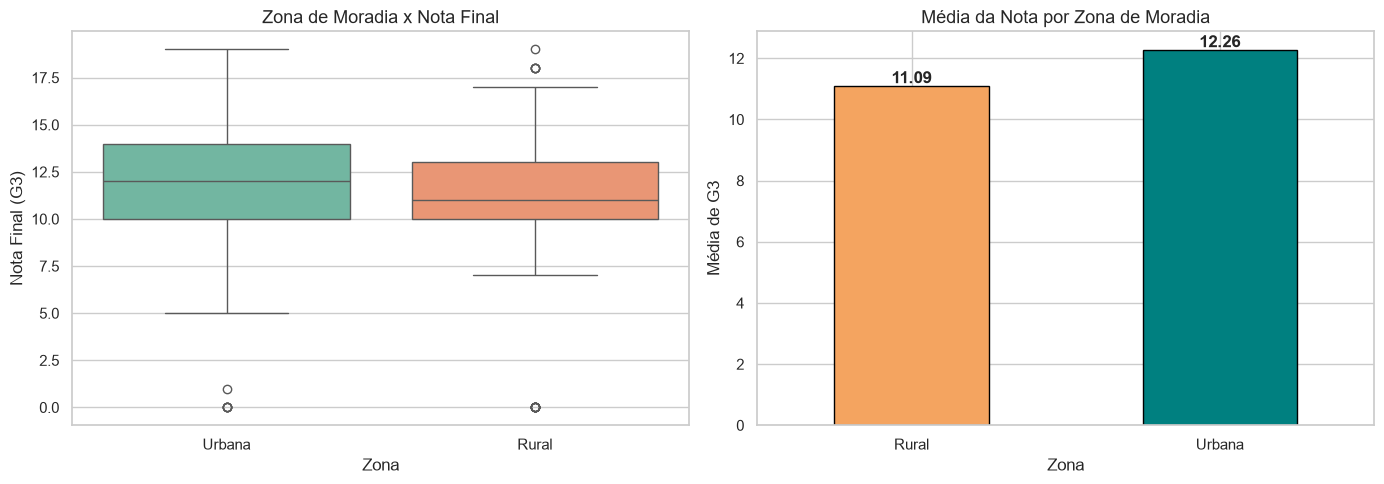

In [12]:
#Zona de moradia x Nota Final
df_addr = df.copy()
df_addr['address'] = df_addr['address'].map({'U': 'Urbana', 'R': 'Rural'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_addr, x='address', y='G3', ax=axes[0], palette='Set2')
axes[0].set_title('Zona de Moradia x Nota Final', fontsize=13)
axes[0].set_xlabel('Zona')
axes[0].set_ylabel('Nota Final (G3)')

medias_addr = df_addr.groupby('address')['G3'].mean()
medias_addr.plot(kind='bar', ax=axes[1], color=['sandybrown', 'teal'], edgecolor='black')
axes[1].set_title('Média da Nota por Zona de Moradia', fontsize=13)
axes[1].set_xlabel('Zona')
axes[1].set_ylabel('Média de G3')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(medias_addr):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Análise Exploratória —> Fatores Acadêmicos

C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\1626136099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='studytime', y='G3', ax=axes[0], palette='YlGn')
C:\Users\sarah\AppData\Local\Temp\ipykernel_10624\1626136099.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='failures', y='G3', ax=axes[1], palette='Reds')


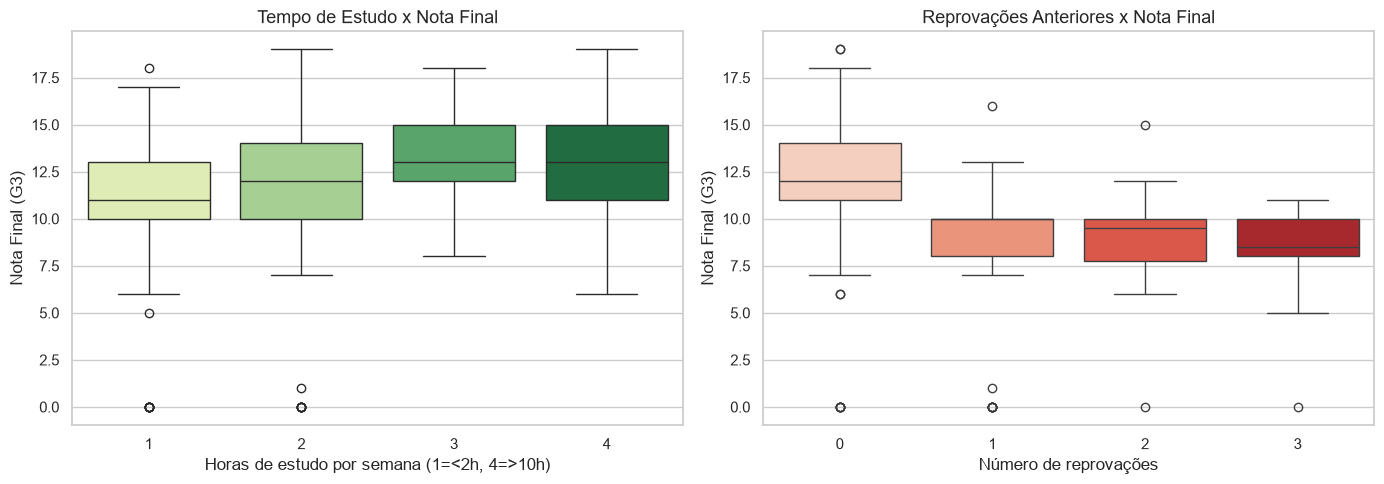

In [13]:
#Tempo de estudo x Nota Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

estudo_labels = {1: '<2h', 2: '2-5h', 3: '5-10h', 4: '>10h'}
df_est = df.copy()
df_est['studytime_label'] = df_est['studytime'].map(estudo_labels)

sns.boxplot(data=df, x='studytime', y='G3', ax=axes[0], palette='YlGn')
axes[0].set_title('Tempo de Estudo x Nota Final', fontsize=13)
axes[0].set_xlabel('Horas de estudo por semana (1=<2h, 4=>10h)')
axes[0].set_ylabel('Nota Final (G3)')

# Reprovações x Nota
sns.boxplot(data=df, x='failures', y='G3', ax=axes[1], palette='Reds')
axes[1].set_title('Reprovações Anteriores x Nota Final', fontsize=13)
axes[1].set_xlabel('Número de reprovações')
axes[1].set_ylabel('Nota Final (G3)')

plt.tight_layout()
plt.show()

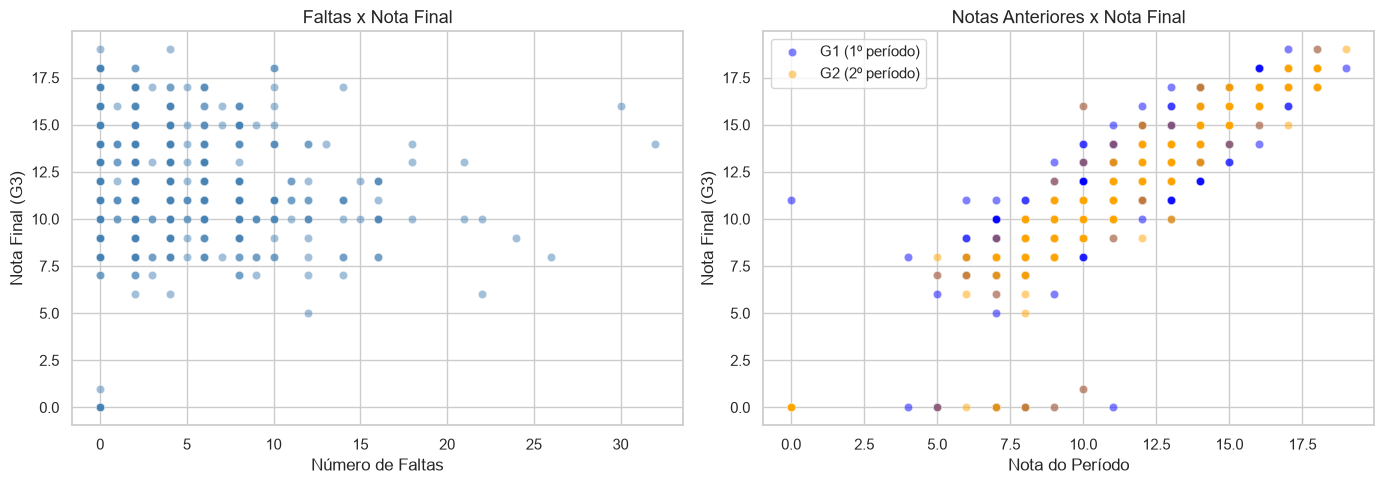

In [14]:
#Faltas x Nota Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='absences', y='G3', ax=axes[0], alpha=0.5, color='steelblue')
axes[0].set_title('Faltas x Nota Final', fontsize=13)
axes[0].set_xlabel('Número de Faltas')
axes[0].set_ylabel('Nota Final (G3)')

# Notas anteriores x Nota Final
sns.scatterplot(data=df, x='G1', y='G3', label='G1 (1º período)', ax=axes[1], alpha=0.5, color='blue')
sns.scatterplot(data=df, x='G2', y='G3', label='G2 (2º período)', ax=axes[1], alpha=0.5, color='orange')
axes[1].set_title('Notas Anteriores x Nota Final', fontsize=13)
axes[1].set_xlabel('Nota do Período')
axes[1].set_ylabel('Nota Final (G3)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Correlações com a Nota Final (G3)

Quais variáveis numéricas têm mais relação com G3?

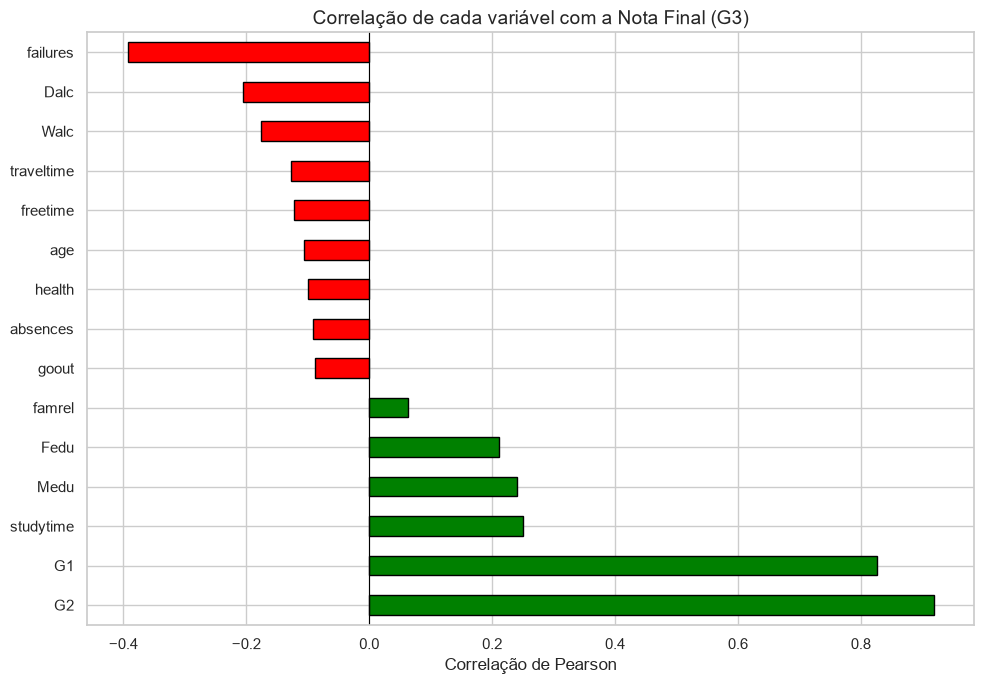


 Correlações:
G2            0.919
G1            0.826
studytime     0.250
Medu          0.240
Fedu          0.212
famrel        0.063
goout        -0.088
absences     -0.091
health       -0.099
age          -0.107
freetime     -0.123
traveltime   -0.127
Walc         -0.177
Dalc         -0.205
failures     -0.393


In [15]:
#Seleciona colunas numéricas
colunas_numericas = df.select_dtypes(include='number').columns.tolist()

#Correlação com G3
correlacoes = df[colunas_numericas].corr()['G3'].drop('G3').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['green' if v > 0 else 'red' for v in correlacoes.values]
correlacoes.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada variável com a Nota Final (G3)', fontsize=14)
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

print('\n Correlações:')
print(correlacoes.round(3).to_string())

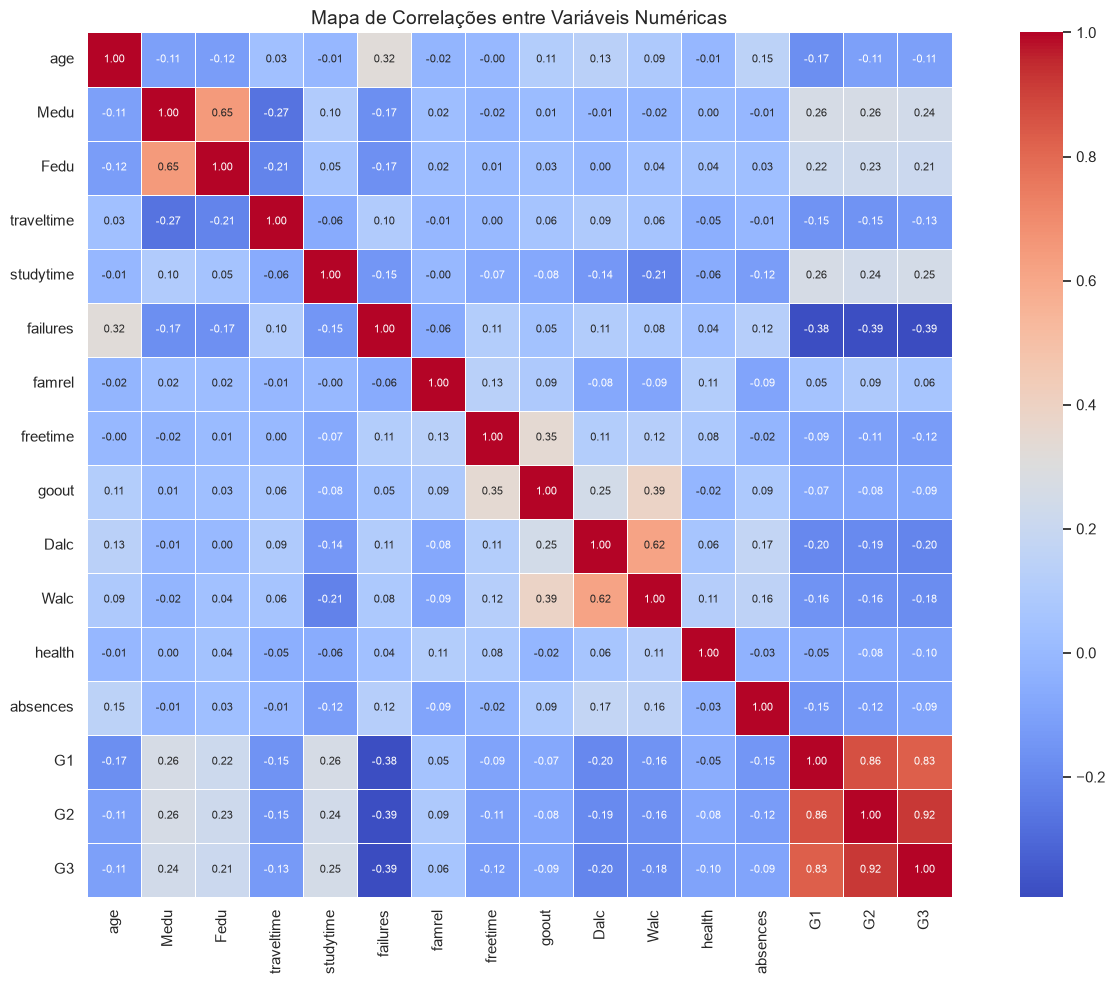

In [16]:
#Mapa de calor — todas as correlações
plt.figure(figsize=(14, 10))
corr_matrix = df[colunas_numericas].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={'size': 8})
plt.title('Mapa de Correlações entre Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Treinamento do Modelo de Regressão Linear

Usaremos as variáveis mais relevantes para prever a nota final (G3).

In [17]:
#Features selecionadas com base na análise anterior
features = ['G1', 'G2', 'studytime', 'failures', 'absences', 'Dalc', 'Walc', 'goout', 'famrel']
target = 'G3'

X = df[features]
y = df[target]

#Divisão treino/teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dados de treino: {X_train.shape[0]} amostras')
print(f'Dados de teste:  {X_test.shape[0]} amostras')

#Treinamento
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('\n Modelo treinado com sucesso!')

Dados de treino: 519 amostras
Dados de teste:  130 amostras

 Modelo treinado com sucesso!


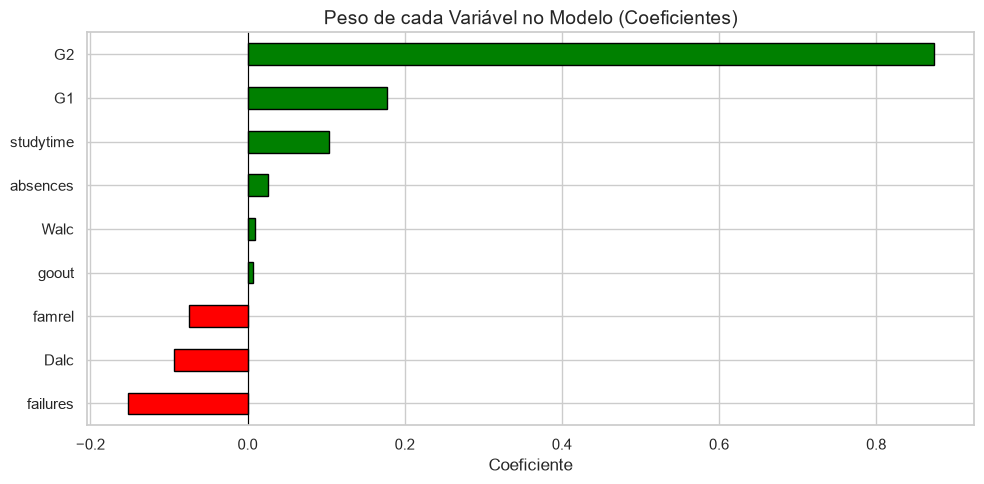


 Coeficientes:
   G1          : +0.1776
   G2          : +0.8732
   studytime   : +0.1040
   failures    : -0.1528
   absences    : +0.0260
   Dalc        : -0.0933
   Walc        : +0.0100
   goout       : +0.0067
   famrel      : -0.0744

   Intercepto: -0.0782


In [18]:
#Peso (coeficiente) de cada variável no modelo
coeficientes = pd.Series(modelo.coef_, index=features).sort_values()

plt.figure(figsize=(10, 5))
colors = ['green' if v > 0 else 'red' for v in coeficientes.values]
coeficientes.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Peso de cada Variável no Modelo (Coeficientes)', fontsize=14)
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('\n Coeficientes:')
for feature, coef in zip(features, modelo.coef_):
    print(f'   {feature:12s}: {coef:+.4f}')
print(f'\n   Intercepto: {modelo.intercept_:.4f}')

---
## 7. Avaliação do Modelo

Aqui verificamos o quão bem o modelo está prevendo as notas.

In [19]:
#Previsões
y_pred = modelo.predict(X_test)

#Métricas
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=== MÉTRICAS DE AVALIAÇÃO ===')
print(f'MAE  (Erro Médio Absoluto):   {mae:.2f} pontos')
print(f'RMSE (Raiz do Erro Quadrático): {rmse:.2f} pontos')
print(f'R²   (Coef. de Determinação):  {r2:.4f} ({r2*100:.1f}% da variação explicada)')

print('\n Interpretação:')
print(f'   O modelo erra, em média, {mae:.2f} pontos na previsão da nota.')
print(f'   Ele consegue explicar {r2*100:.1f}% da variação nas notas.')

=== MÉTRICAS DE AVALIAÇÃO ===
MAE  (Erro Médio Absoluto):   0.74 pontos
RMSE (Raiz do Erro Quadrático): 1.15 pontos
R²   (Coef. de Determinação):  0.8634 (86.3% da variação explicada)

 Interpretação:
   O modelo erra, em média, 0.74 pontos na previsão da nota.
   Ele consegue explicar 86.3% da variação nas notas.


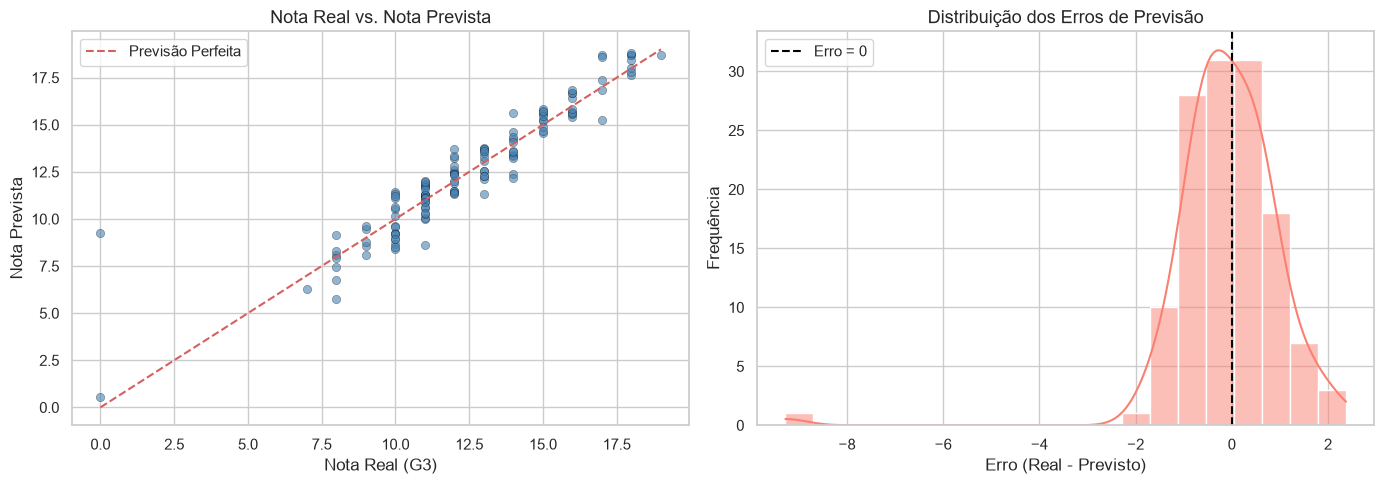

In [20]:
#Gráfico: Nota Real vs Nota Prevista
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Scatter: real vs previsto
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black', linewidths=0.3)
#Linha perfeita (se o modelo acertasse tudo)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Previsão Perfeita')
axes[0].set_title('Nota Real vs. Nota Prevista', fontsize=13)
axes[0].set_xlabel('Nota Real (G3)')
axes[0].set_ylabel('Nota Prevista')
axes[0].legend()

#Distribuição dos erros
erros = y_test.values - y_pred
sns.histplot(erros, bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(0, color='black', linestyle='--', label='Erro = 0')
axes[1].set_title('Distribuição dos Erros de Previsão', fontsize=13)
axes[1].set_xlabel('Erro (Real - Previsto)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
#Tabela comparativa: Real vs Previsto
comparacao = pd.DataFrame({
    'Nota Real (G3)': y_test.values,
    'Nota Prevista':  y_pred.round(1),
    'Erro':           (y_test.values - y_pred).round(1)
})

print('Primeiras 15 previsões:')
print(comparacao.head(15).to_string(index=False))

Primeiras 15 previsões:
 Nota Real (G3)  Nota Prevista  Erro
             19           18.7   0.3
             12           11.4   0.6
             18           18.7  -0.7
             11           11.2  -0.2
             11           11.8  -0.8
             17           16.8   0.2
             18           17.6   0.4
              8            9.2  -1.2
             10           10.6  -0.6
             11           10.6   0.4
             18           18.7  -0.7
             11           12.0  -1.0
             12           12.4  -0.4
              9            9.5  -0.5
             12           11.9   0.1


In [22]:
#Exemplo: prever a nota de um aluno hipotético
# [G1, G2, studytime, failures, absences, Dalc, Walc, goout, famrel]
aluno_exemplo = np.array([[10, 12, 2, 0, 4, 1, 2, 3, 4]])

nota_prevista = modelo.predict(aluno_exemplo)[0]

print('=== PREVISÃO PARA ALUNO HIPOTÉTICO ===')
print(f'Nota no 1º período (G1):     10')
print(f'Nota no 2º período (G2):     12')
print(f'Horas de estudo semanais:    2 (entre 2h e 5h)')
print(f'Reprovações anteriores:      0')
print(f'Número de faltas:            4')
print(f'Álcool dias úteis (1-5):     1')
print(f'Álcool fim de semana (1-5):  2')
print(f'Sair com amigos (1-5):       3')
print(f'Relação familiar (1-5):      4')
print(f'\n Nota final prevista: {nota_prevista:.2f}')

=== PREVISÃO PARA ALUNO HIPOTÉTICO ===
Nota no 1º período (G1):     10
Nota no 2º período (G2):     12
Horas de estudo semanais:    2 (entre 2h e 5h)
Reprovações anteriores:      0
Número de faltas:            4
Álcool dias úteis (1-5):     1
Álcool fim de semana (1-5):  2
Sair com amigos (1-5):       3
Relação familiar (1-5):      4

 Nota final prevista: 12.14


c:\Users\sarah\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
